# Predict Fuel Efficiency Using Tensorflow in Python

Predicting fuel efficiency is a important task in automotive design and environmental sustainability. In this notebook we will build a fuel efficiency prediction model using TensorFlow one of the most popular deep learning libraries.

We will use the Auto MPG dataset which contains features like engine displacement, horsepower, weight and other car specifications to predict miles per gallon (MPG).

## Step 1: Import Required Libraries
Before we begin let’s import the necessary libraries: numpy, pandas, matplotlib, seaborn and tensorflow for data processing, model building and visualization.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

import tensorflow as tf
from tensorflow import keras
from keras import layers

import warnings
warnings.filterwarnings('ignore')

d:\mini projects\projects\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## Step 2: Load the Dataset
The dataset we’ll use is the Auto MPG dataset which contains information about cars manufactured between 1970 and 1982. Let’s load the dataset and inspect its structure.

In [2]:
df = pd.read_csv('auto-mpg.csv')
print(df.head())

    mpg  cylinders  displacement horsepower  weight  acceleration  model year  \
0  18.0          8         307.0        130    3504          12.0          70   
1  15.0          8         350.0        165    3693          11.5          70   
2  18.0          8         318.0        150    3436          11.0          70   
3  16.0          8         304.0        150    3433          12.0          70   
4  17.0          8         302.0        140    3449          10.5          70   

   origin                   car name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  


Let's check the shape of the data.

In [3]:
df.shape

(398, 9)

## Step 3: Exploratory Data Analysis (EDA)
Let’s explore the dataset to understand its structure and identify any inconsistencies.

First we will check the datatypes of the columns using df.info() function.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


The key information related to dataset are:

* 398 rows of data, with the indices ranging from 0 to 397
* all columns have non-null values, meaning there is no missing data points
* the dataset takes up 28.1 KB of memory

Here, we can observe one discrepancy the horsepower column is given in the object datatype whereas it should be in the numeric datatype.

To understand the numerical characteristics of the dataset, we use df.describe().

In [5]:
df.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


**Data Cleaning**\
As per the df.info() part first we will deal with the horsepower column and then we will move toward the analysis part.

In [6]:
df['horsepower'].unique()

array(['130', '165', '150', '140', '198', '220', '215', '225', '190',
       '170', '160', '95', '97', '85', '88', '46', '87', '90', '113',
       '200', '210', '193', '?', '100', '105', '175', '153', '180', '110',
       '72', '86', '70', '76', '65', '69', '60', '80', '54', '208', '155',
       '112', '92', '145', '137', '158', '167', '94', '107', '230', '49',
       '75', '91', '122', '67', '83', '78', '52', '61', '93', '148',
       '129', '96', '71', '98', '115', '53', '81', '79', '120', '152',
       '102', '108', '68', '58', '149', '89', '63', '48', '66', '139',
       '103', '125', '133', '138', '135', '142', '77', '62', '132', '84',
       '64', '74', '116', '82'], dtype=object)

Here we can observe that instead of the null they have been replaced by the string '?' due to this, the data of this column has been provided in the object datatype.

In [7]:
print(df.shape)
df = df[df['horsepower'] != '?']
print(df.shape)

(398, 9)
(392, 9)


After this operation, the shape of the dataset decreases from 398 to 392 rows, indicating that we removed 6 rows with invalid values.

Next, we convert the horsepower column to an integer type:

In [8]:
df['horsepower'] = df['horsepower'].astype(int)
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [9]:
df.nunique()

mpg             127
cylinders         5
displacement     81
horsepower       93
weight          346
acceleration     95
model year       13
origin            3
car name        301
dtype: int64

**Visualizing the Impact of Categorical Variables on MPG**

Now, let's explore the effect of categorical features like cylinders and origin on the target variable mpg (miles per gallon). We plot bar charts to show the average mpg for different values of cylinders and origin:

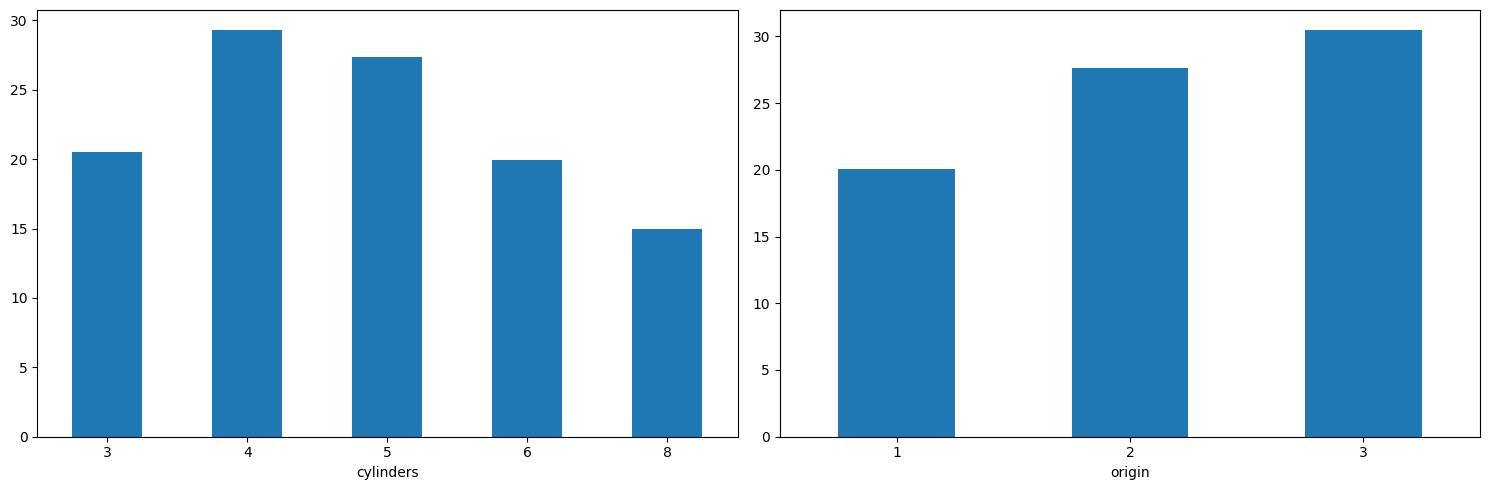

In [11]:
# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(15, 5))
for i, col in enumerate(['cylinders', 'origin']):
    plt.subplot(1, 2, i+1)
    x = numeric_df.groupby(col).mean()['mpg']
    x.plot.bar()
    plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

From this analysis, we observe that the highest mpg values are associated with origin 3 (likely foreign cars).

**Correlation Analysis**\
Next, we explore the relationships between numeric features. We start by plotting the correlation matrix to identify potential multicollinearity issues:

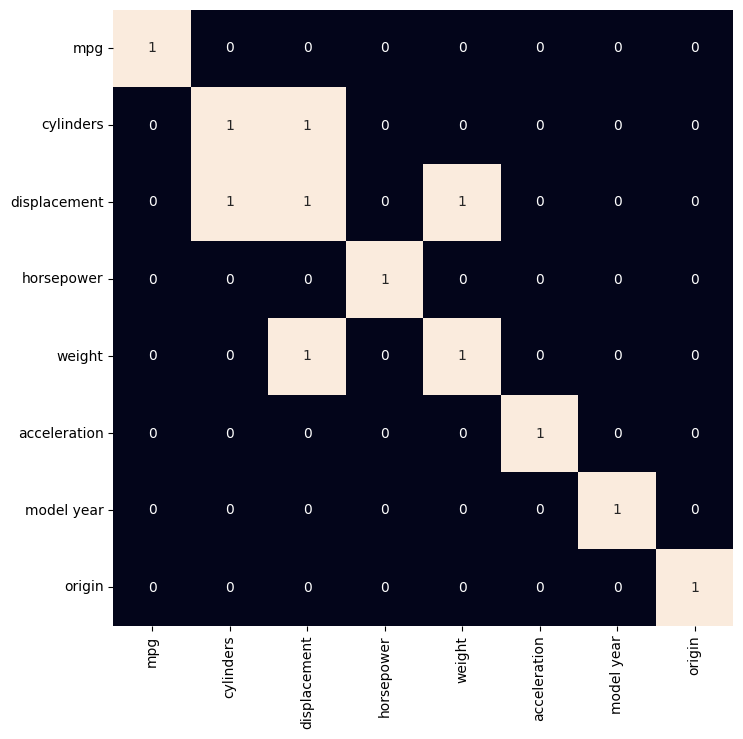

In [12]:
plt.figure(figsize=(8, 8)) 
sb.heatmap(numeric_df.corr() > 0.9, 
		annot=True, 
		cbar=False) 
plt.show()

If the correlation between two features is too high (i.e., above 0.9), it might cause multicollinearity. In our case, displacement and other features like horsepower and weight might be highly correlated. To address this, we remove displacement using df.drop():

In [13]:
df.drop('displacement',
        axis=1,
        inplace=True)

## Step 4: Data Preprocessing
**Split Data into Features and Target**\
We now split the dataset into features (independent variables) and target (dependent variable):

In [14]:
from sklearn.model_selection import train_test_split
features = df.drop(['mpg', 'car name'], axis=1)
target = df['mpg'].values

X_train, X_val, \
    Y_train, Y_val = train_test_split(features, target,
                                      test_size=0.2,
                                      random_state=22)
X_train.shape, X_val.shape

((313, 6), (79, 6))

After splitting, the training set contains 313 rows, and the validation set contains 79 rows.

**Create TensorFlow Data Pipeline**

We use TensorFlow to create a data pipeline for efficient training and validation. This involves batching and prefetching the data for better performance:

In [15]:
AUTO = tf.data.experimental.AUTOTUNE

train_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_train, Y_train))
    .batch(32)
    .prefetch(AUTO)
)

val_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_val, Y_val))
    .batch(32)
    .prefetch(AUTO)
)

## Step 5: Define the Model
We now define the model using Keras' Sequential API. The model consists of two fully connected layers, each with 256 neurons.

Batch normalization layers are added for stable and faster training, and a dropout layer is included to prevent overfitting.

In [16]:
model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=[6]),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(1, activation='relu')
])

Next, we compile the model by specifying the:

* optimizer (adam)
* loss function (mae for Mean Absolute Error)
* evaluation metric (mape for Mean Absolute Percentage Error):

In [17]:
model.compile(
    loss='mae',
    optimizer='adam',
    metrics=['mape']
)

Let’s print the summary of the model’s architecture:

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,889 (273.00 KB)

 Trainable params: 68,865 (269.00 KB)

 Non-trainable params: 1,024 (4.00 KB)

This shows the number of parameters and the structure of each layer.

## Step 6: Model Training
We train the model for 50 epochs using the training and validation datasets. The training process will optimize the model based on the loss and metric we defined earlier:

In [19]:
history = model.fit(train_ds,
                    epochs=50,
                    validation_data=val_ds)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 21.2206 - mape: 84.6017 - val_loss: 30.6878 - val_mape: 188.0036
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 19.6302 - mape: 75.1576 - val_loss: 21.9750 - val_mape: 133.4311
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 18.9729 - mape: 71.9375 - val_loss: 14.7725 - val_mape: 81.3723
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 18.4613 - mape: 69.4007 - val_loss: 11.8619 - val_mape: 55.9257
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 17.7763 - mape: 65.8858 - val_loss: 10.6182 - val_mape: 44.4095
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 17.2406 - mape: 63.4056 - val_loss: 10.0523 - val_mape: 39.4533
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 16.6494 - mape: 60.7212 - val_loss: 9.5630 - val_mape: 36.4802
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 16.0330 - mape: 58.1194 - val_loss: 9.4502 - val_mape: 36.5919
Epoch 9/50
10/10

## Step 7: Evaluate the Model
After training, we plot the training and validation metrics (loss and mape) to evaluate the model's performance:

In [20]:
history_df = pd.DataFrame(history.history)
history_df.head()

,loss,mape,val_loss,val_mape
0,21.220575,84.601662,30.687780,188.003555
1,19.630196,75.157555,21.975000,133.431107
2,18.972879,71.937454,14.772451,81.372330
3,18.461315,69.400681,11.861931,55.925682
4,17.776257,65.885773,10.618152,44.409470


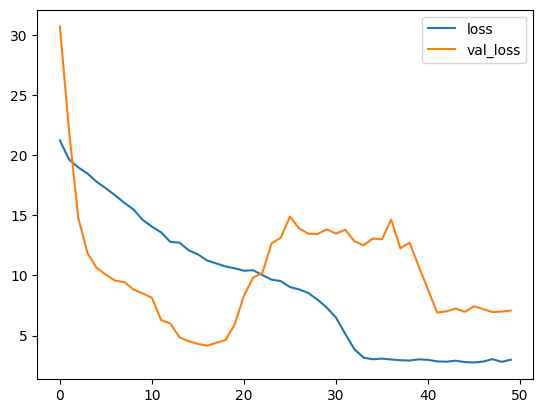

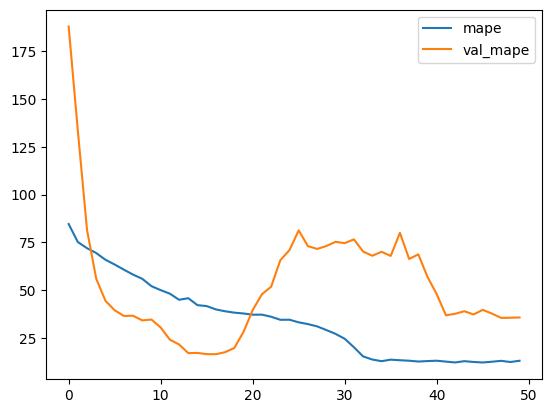

In [21]:
history_df.loc[:, ['loss', 'val_loss']].plot()
history_df.loc[:, ['mape', 'val_mape']].plot()
plt.show()

After training, we plot the training and validation metrics (loss and mape) to evaluate the model's performance:

The model consists of dense layers with batch normalization and dropout to prevent overfitting, and it is trained using TensorFlow. The evaluation of the training and validation losses and metrics provides insight into the model's performance.